## Table of Contents

1. Importing Libraries and Dataframes  
2. Data Security Implications  
3. Create a regional segmentation of the data  
4. Create an exclusion flag for low-activity customers  
5. Customer Profiling Based on Demographics and Shopping Behavior  
6. Aggregate the max, mean, and min variables on a customer-profile level for usage frequency and expenditure.  
7. Compare your customer profiles with regions and departments.  
8. Linking the Charts to Insights

**Submitted by: Unaza Ali**


 # Importing Libraries and Dataframes

In [3]:
# Importing Libraries
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import scipy

In [4]:
# Define the file path
path = '/Users/muhammaddildar/Desktop/03-2025 Instacart Basket Analysis'

In [5]:
# Import the merged data from Exercise 4.9 (with the new customers column)
df = pd.read_pickle(os.path.join(path, 'Data', 'Prepared Data', 'ords_prods_cust_merge.pkl'))

In [6]:
# Check the first few rows to confirm the data is loaded correctly
df.head()

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_id,add_to_cart_order,reordered,_merge,...,First Name,Last Name,Gender,State,Age,Date Joined,Number of Dependents,Family Status,Income,Region
0,2539329,1,1,2,8,11.104079,196,1,0,both,...,Linda,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South
1,2539329,1,1,2,8,11.104079,14084,2,0,both,...,Linda,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South
2,2539329,1,1,2,8,11.104079,12427,3,0,both,...,Linda,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South
3,2539329,1,1,2,8,11.104079,26088,4,0,both,...,Linda,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South
4,2539329,1,1,2,8,11.104079,26405,5,0,both,...,Linda,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South


# Data Security Implications

In this dataset, there may be **Personally Identifiable Information (PII)** such as names, addresses, email addresses, and other sensitive data that could potentially be linked to specific individuals. The presence of **user_id**, **order_id**, and other demographic details like **age**, **income**, and **state of residence** may also contain information that could identify individuals, depending on the level of granularity.

As part of good data security practices:
1. **Informing the Senior Colleague**: Any concerns related to PII should be raised with senior colleagues or the data security team for advice on how to handle sensitive information.
   
2. **Compliance with Regulations**: We must ensure compliance with relevant **EU data privacy regulations** (e.g., GDPR) governing the storage, usage, and sharing of PII. This includes anonymizing or pseudonymizing sensitive data when necessary and taking proper precautions when sharing the data.

**Note**: If PII is found in this dataset, actions such as pseudonymization or anonymization might be performed to ensure privacy during analysis.

# Create a regional segmentation of the data
-Use the region information in this Wikipedia article to create your column (you only need to create regions, not divisions).

-Determine whether there’s a difference in spending habits between the different U.S. regions. (Hint: You can do this by crossing the variable you just created with the spending flag.)

In [9]:
# Define a mapping for states to regions
region_map = {
    'Maine': 'Northeast', 'New Hampshire': 'Northeast', 'Vermont': 'Northeast', 'Massachusetts': 'Northeast',
    'Rhode Island': 'Northeast', 'Connecticut': 'Northeast', 'New York': 'Northeast', 'New Jersey': 'Northeast', 
    'Pennsylvania': 'Northeast',
    
    'Ohio': 'Midwest', 'Indiana': 'Midwest', 'Illinois': 'Midwest', 'Michigan': 'Midwest', 'Wisconsin': 'Midwest', 
    'Missouri': 'Midwest', 'Iowa': 'Midwest', 'Minnesota': 'Midwest', 'North Dakota': 'Midwest', 'South Dakota': 'Midwest',
    'Nebraska': 'Midwest', 'Kansas': 'Midwest',
    
    'Delaware': 'South', 'Maryland': 'South', 'Virginia': 'South', 'West Virginia': 'South', 'North Carolina': 'South',
    'South Carolina': 'South', 'Georgia': 'South', 'Florida': 'South', 'Alabama': 'South', 'Kentucky': 'South',
    'Tennessee': 'South', 'Mississippi': 'South', 'Arkansas': 'South', 'Louisiana': 'South', 'Oklahoma': 'South',
    'Texas': 'South',
    
    'Montana': 'West', 'Wyoming': 'West', 'Colorado': 'West', 'New Mexico': 'West', 'Arizona': 'West', 'Utah': 'West',
    'Nevada': 'West', 'Idaho': 'West', 'Washington': 'West', 'Oregon': 'West', 'California': 'West', 'Alaska': 'West', 'Hawaii': 'West'
}
# Replace 'District of Columbia' with a region (e.g., Northeast)
df['State'] = df['State'].replace('District of Columbia', 'Northeast')

# Re-run the region mapping to assign regions based on the 'State' column
df['Region'] = df['State'].map(region_map)

# Drop rows with missing regions (NaN) after re-mapping
df = df.dropna(subset=['Region'])

# Optional: Display the first few rows to check the final dataset
df.head()

# Create the 'Region' column based on the 'State' column
df['Region'] = df['State'].map(region_map)

# Check the first few rows to confirm the new 'Region' column
df.head()

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_id,add_to_cart_order,reordered,_merge,...,First Name,Last Name,Gender,State,Age,Date Joined,Number of Dependents,Family Status,Income,Region
0,2539329,1,1,2,8,11.104079,196,1,0,both,...,Linda,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South
1,2539329,1,1,2,8,11.104079,14084,2,0,both,...,Linda,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South
2,2539329,1,1,2,8,11.104079,12427,3,0,both,...,Linda,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South
3,2539329,1,1,2,8,11.104079,26088,4,0,both,...,Linda,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South
4,2539329,1,1,2,8,11.104079,26405,5,0,both,...,Linda,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South


In [10]:
df['Region'].value_counts(dropna = False)

Region
South        10186740
West          8300005
Midwest       7603395
Northeast     5728051
Name: count, dtype: int64

In [11]:
#Comparing it to total counts of the dataset
df.shape

(31818191, 35)

#### The total count of rows (31,818,191) matches the sum of the values across all four regions. Since there are no missing values (NaN), we can confidently conclude that the regional segmentation was performed correctly.

In [13]:
# Determine whether there’s a difference in spending habits between the different U.S. regions. (Hint: You can do this by crossing the variable you just created with the spending flag.)

In [14]:
crosstab = pd.crosstab(df['Region'],df['spending_flag'], dropna = False)
crosstab.to_clipboard()

## Regional Spending Habits

This table shows the distribution of **high spenders** and **low spenders** across different U.S. regions:

| Region    | High spender | Low spender |
|-----------|--------------|-------------|
| Midwest   | 156,120      | 7,447,275   |
| Northeast | 108,339      | 5,619,712   |
| South     | 197,467      | 9,989,273   |
| West      | 160,806      | 8,139,199   |

As shown, the **South** region has the highest number of low spenders, while the **Midwest** region has the least. 
The high spender counts are relatively balanced across the regions, with the **South** region showing the highest count in this category.


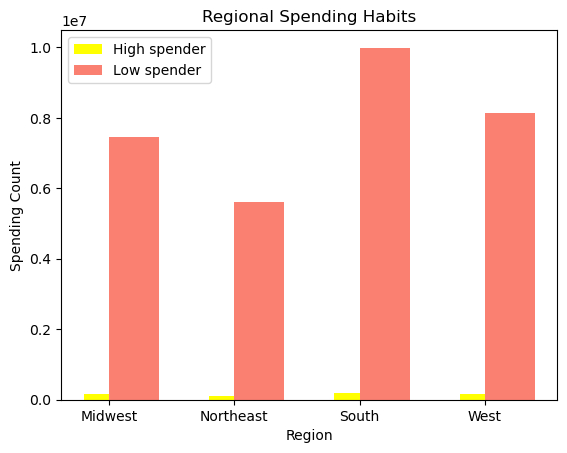

Chart saved in: /Users/muhammaddildar/Desktop/03-2025 Instacart Basket Analysis/Analysis/Visualizations/Regional_Spending_Habits_BarChart.png


In [102]:
# Group by 'Region' and 'spending_flag' and count the occurrences
spending_by_region = df.groupby(['Region', 'spending_flag']).size().unstack(fill_value=0)

# Extract high_spender and low_spender from the correct columns
high_spender = spending_by_region['High spender'].values
low_spender = spending_by_region['Low spender'].values

# Plot the bar chart
plt.bar(spending_by_region.index, high_spender, width=0.4, label='High spender', align='center', color='yellow')
plt.bar(spending_by_region.index, low_spender, width=0.4, label='Low spender', align='edge', color='salmon')

# Add labels, title, and legend
plt.xlabel('Region')
plt.ylabel('Spending Count')
plt.title('Regional Spending Habits')
plt.legend()

# Save the chart as a PNG file
save_path = os.path.join(path, 'Analysis', 'Visualizations', 'Regional_Spending_Habits_BarChart.png')
plt.savefig(save_path, bbox_inches='tight')

# Show the chart
plt.show()

# Close the plot to avoid issues with saving the figure
plt.close()

# Confirm the file is saved
print(f"Chart saved in: {save_path}")


In [16]:
# Export the updated Dataframe
df.to_pickle(os.path.join(path, 'Data', 'Prepared Data', 'ords_prods_cust_merge.pkl'))

## Observation:

The distribution of spenders is spread across multiple regions, making it difficult to determine which region has the highest concentration of spenders. Drawing conclusions based solely on this data may lead to inaccurate assumptions, as other factors could be influencing the spending habits, causing the results to appear scattered.

# Create an exclusion flag for low-activity customers 
(customers with less than 5 orders) and exclude them from the data.

In [19]:
# Create a exclusion flag for the low activity customers(less than 5 orders)
df.loc[df['max_order'] < 5, 'Customer_Activity'] = 'LOW'
df.loc[df['max_order'] >= 5, 'Customer_Activity'] = 'HIGH'

In [20]:
# Verify the newly generated Customer_Activity Column in the Dataframe
df.head()

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_id,add_to_cart_order,reordered,_merge,...,Last Name,Gender,State,Age,Date Joined,Number of Dependents,Family Status,Income,Region,Customer_Activity
0,2539329,1,1,2,8,11.104079,196,1,0,both,...,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,HIGH
1,2539329,1,1,2,8,11.104079,14084,2,0,both,...,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,HIGH
2,2539329,1,1,2,8,11.104079,12427,3,0,both,...,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,HIGH
3,2539329,1,1,2,8,11.104079,26088,4,0,both,...,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,HIGH
4,2539329,1,1,2,8,11.104079,26405,5,0,both,...,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,HIGH


In [21]:
# Verify the rows and columns in the Dataframe
df.shape

(31818191, 36)

In [22]:
# Count of the Customer_Activity Column
df['Customer_Activity'].value_counts(dropna = False)

Customer_Activity
HIGH    30403609
LOW      1414582
Name: count, dtype: int64

In [23]:
# Exclude the low activity customers from the Dataframe
Updated_df = df[df['Customer_Activity'] != 'LOW']

In [24]:
# Export the updated dataframe
Updated_df.to_pickle(os.path.join(path, 'Data', 'Prepared Data', 'High_actv_cust.pkl'))

# Customer Profiling Based on Demographics and Shopping Behavior

## Age Variable Group

In [27]:
# Generate an Age Group Variable (Correct way to avoid warning)
Updated_df.loc[Updated_df['Age'] <= 25, 'Age Group'] = 'Youth'
Updated_df.loc[(Updated_df['Age'] > 25) & (Updated_df['Age'] <= 64), 'Age Group'] = 'Adults'
Updated_df.loc[Updated_df['Age'] > 64, 'Age Group'] = 'Senior'


/var/folders/9f/2_mg72bd2q7cnfbcyf1x4dnw0000gn/T/ipykernel_63054/2550696127.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Updated_df.loc[Updated_df['Age'] <= 25, 'Age Group'] = 'Youth'


In [28]:
# Verify the Age Group Variable
Count_AgeGroup = Updated_df['Age Group'].value_counts(dropna = False)

In [29]:
Count_AgeGroup

Age Group
Adults    18561178
Senior     8049307
Youth      3793124
Name: count, dtype: int64

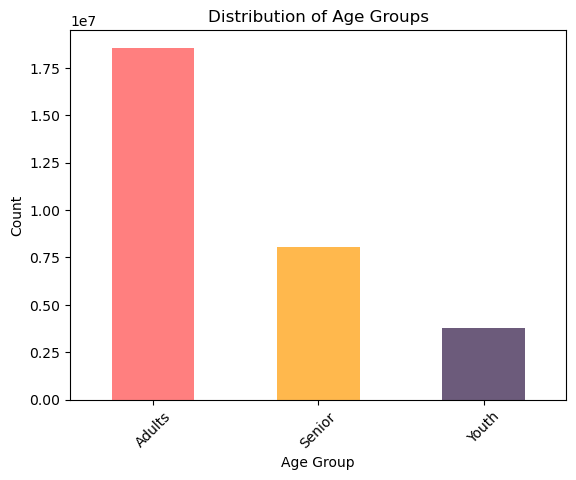

In [30]:
# Visualize a bar chart with customized colors
AgeGroup_BarChart = Count_AgeGroup.plot.bar(color=['#FF7F7F', '#FFB84D', '#6C5B7B'])  # Change colors here

# Add title and labels
plt.title('Distribution of Age Groups')
plt.xlabel('Age Group')
plt.ylabel('Count')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Show the chart
plt.show()


In [31]:
# Export the bar chart
AgeGroup_BarChart.figure.savefig(os.path.join(path, 'Analysis','Visualizations', 'AgeGroup_BarChart.png'))

## Income Variable Group

In [33]:
# Generate an Income Group Variable
Updated_df.loc[Updated_df['Income'] <= 50000, 'Income Group'] = 'LOW'
Updated_df.loc[(Updated_df['Income'] > 50000) & (Updated_df['Income'] <= 150000), 'Income Group'] = 'MIDDLE'
Updated_df.loc[Updated_df['Income'] > 150000, 'Income Group'] = 'HIGH'

/var/folders/9f/2_mg72bd2q7cnfbcyf1x4dnw0000gn/T/ipykernel_63054/3196235115.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Updated_df.loc[Updated_df['Income'] <= 50000, 'Income Group'] = 'LOW'


In [34]:
# Verify the Income Group Variable
Count_IncomeGroup = Updated_df['Income Group'].value_counts(dropna = False)

In [35]:
Count_IncomeGroup

Income Group
MIDDLE    23280153
HIGH       3819363
LOW        3304093
Name: count, dtype: int64

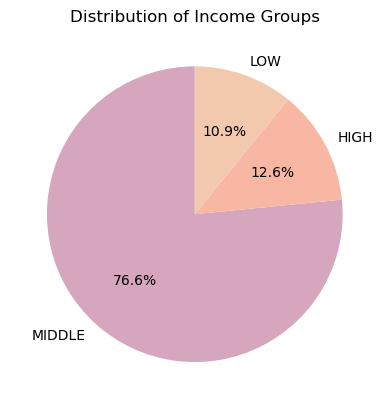

In [36]:
# Visualize a pie chart
IncomeGroup_PieChart = Count_IncomeGroup.plot.pie(autopct='%1.1f%%', startangle=90, colors=['#D5A6BD', '#F7B7A3', '#F2C9AC'])
plt.title('Distribution of Income Groups')
# Hide the y-label
plt.ylabel('')
plt.show()


In [37]:
# Export the pie chart
IncomeGroup_PieChart.figure.savefig(os.path.join(path, 'Analysis','Visualizations', 'IncomeGroup_PieChart.png'))

### Number of Dependant Variable

In [39]:
# Generate a dependent flag variable
Updated_df.loc[Updated_df['Number of Dependents'] == 0, 'dependents_flag'] = 'No Dependents'
Updated_df.loc[Updated_df['Number of Dependents'] >= 1, 'dependents_flag'] = 'Has Dependents'

/var/folders/9f/2_mg72bd2q7cnfbcyf1x4dnw0000gn/T/ipykernel_63054/2841147312.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Updated_df.loc[Updated_df['Number of Dependents'] == 0, 'dependents_flag'] = 'No Dependents'


In [40]:
# Verify the Dependent Variable
Count_DependentGroup = Updated_df['dependents_flag'].value_counts(dropna = False)

In [41]:
Count_DependentGroup

dependents_flag
Has Dependents    22799809
No Dependents      7603800
Name: count, dtype: int64

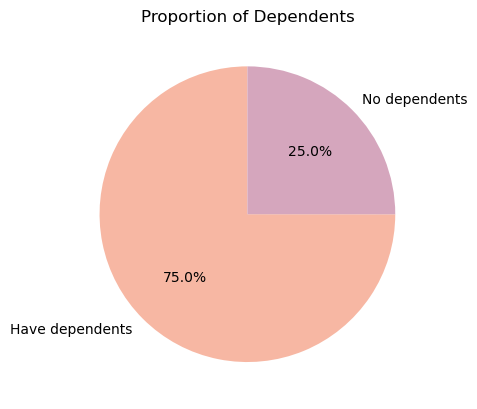

In [42]:
# Visualize a pie chart
DependentGroup_PieChart = Count_DependentGroup.plot.pie(autopct='%1.1f%%', labels= ['Have dependents', 'No dependents'], startangle=90, colors=['#F7B7A3','#D5A6BD'])
# Hide the y-label
plt.ylabel('')  
plt.title('Proportion of Dependents')
plt.show()

In [43]:
# Export the pie chart
DependentGroup_PieChart.figure.savefig(os.path.join(path, 'Analysis','Visualizations', 'DependentGroup_PieChart.png'))

### Certain goods in the “department_id" Variable

In [45]:
# Importe department Dataframe
Df_Dept = pd.read_csv(os.path.join(path, 'Data', 'Prepared Data', 'department_wrangled.csv'))

In [46]:
Df_Dept

,Unnamed: 0,department
0,1,frozen
1,2,other
2,3,bakery
3,4,produce
4,5,alcohol
5,6,international
6,7,beverages
7,8,pets
8,9,dry goods pasta
9,10,bulk


In [47]:
# Rename the unnamed column to deptment_id
Df_Dept.rename(columns={'Unnamed: 0': 'department_id'}, inplace=True)

In [48]:
Df_Dept.columns

Index(['department_id', 'department'], dtype='object')

In [49]:
Updated_df.columns

Index(['order_id', 'user_id', 'order_number', 'order_dow', 'order_hour_of_day',
       'days_since_prior_order', 'product_id', 'add_to_cart_order',
       'reordered', '_merge', 'product_name', 'aisle_id', 'department_id',
       'prices', 'price_range_loc', 'busiest_day', 'busiest_day_updated',
       'slowest_day_updated', 'busiest_period_of_day', 'max_order',
       'loyalty_flag', 'avg_price', 'spending_flag', 'median_days',
       'order_frequency_flag', 'First Name', 'Last Name', 'Gender', 'State',
       'Age', 'Date Joined', 'Number of Dependents', 'Family Status', 'Income',
       'Region', 'Customer_Activity', 'Age Group', 'Income Group',
       'dependents_flag'],
      dtype='object')

In [50]:
# Check the number of rows in both dataframes
print(f"Updated_df size: {Updated_df.shape[0]}")
print(f"Df_Dept size: {Df_Dept.shape[0]}")


Updated_df size: 30403609
Df_Dept size: 21


In [51]:
# Sample with replacement for both dataframes
sample_updated_df = Updated_df.sample(1000, replace=True)
sample_df_dept = Df_Dept.sample(1000, replace=True)

# Now try merging the sample
merged_sample_df = sample_updated_df.merge(sample_df_dept, on='department_id', how='left')


In [52]:
# Visualize a bar chart of Products ordered by Department
BarChart_Department = merged_sample_df['department'].value_counts(ascending = True)

In [53]:
BarChart_Department

department
pets                  94
other                100
missing              104
alcohol              160
international        255
babies               481
personal care        580
meat seafood         624
breakfast            920
household           1300
dry goods pasta     1305
deli                1944
frozen              1972
canned goods        2288
bakery              2548
pantry              3445
beverages           3478
snacks              4332
dairy eggs          8466
produce            15504
Name: count, dtype: int64

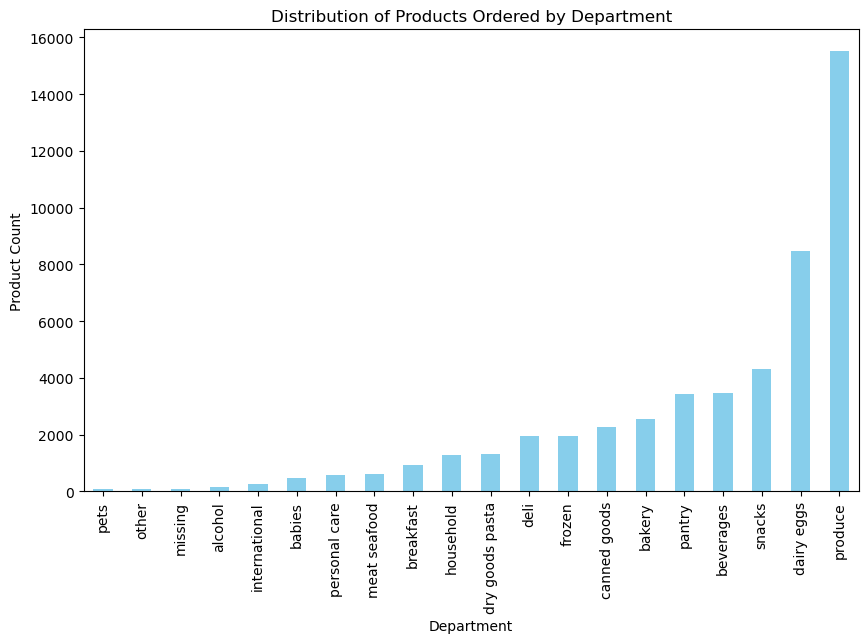

In [54]:
BarChart_Department = merged_sample_df['department'].value_counts(ascending=True)

# Plot the bar chart
BarChart_Department.plot(kind='bar', color='skyblue', figsize=(10, 6))

# Add title and labels
plt.title('Distribution of Products Ordered by Department')
plt.xlabel('Department')
plt.ylabel('Product Count')

# Display the chart
plt.xticks(rotation=90)
plt.show()

In [55]:
# Export the Chart
plt.savefig(os.path.join(path, 'Analysis', 'Visualizations', 'BarChart_Department.png'))

<Figure size 640x480 with 0 Axes>

In [56]:
# Using crosstab functiion on loyalty_flag and Age Group
Crosstab_LoyaltyAgeGroup = pd.crosstab(Updated_df['loyalty_flag'], Updated_df['Age Group'], dropna = False)

In [57]:
Crosstab_LoyaltyAgeGroup

Age Group,Adults,Senior,Youth
loyalty_flag,,,
Loyal customer,6170099,2674387,1254494
New customer,2874499,1252080,585891
Regular customer,9516580,4122840,1952739


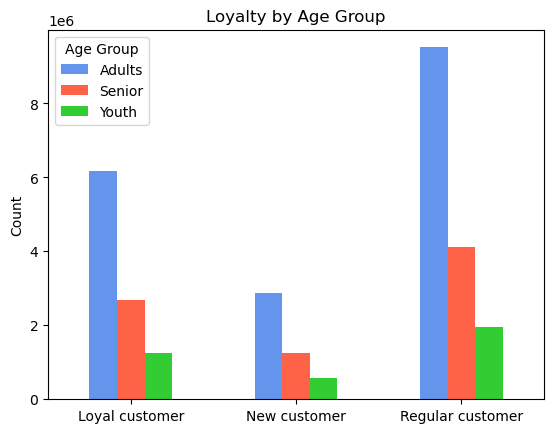

In [58]:
# Visualize a bar chart for the crosstab between loyalty_flag and Age Group with custom colors
LoyaltyAgeGroup_BarChart = Crosstab_LoyaltyAgeGroup.plot.bar(color=['#6495ED', '#FF6347', '#32CD32'])  
plt.title('Loyalty by Age Group')
plt.xlabel('')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

In [59]:
# Using crosstab functiion on spender_flag and Age Group
Crosstab_SpenderAgeGroup = pd.crosstab(Updated_df['spending_flag'], Updated_df['Age Group'], dropna = False)

In [60]:
Crosstab_SpenderAgeGroup

Age Group,Adults,Senior,Youth
spending_flag,,,
High spender,366988,153126,72271
Low spender,18194190,7896181,3720853


(array([0, 1]), [Text(0, 0, 'High spender'), Text(1, 0, 'Low spender')])

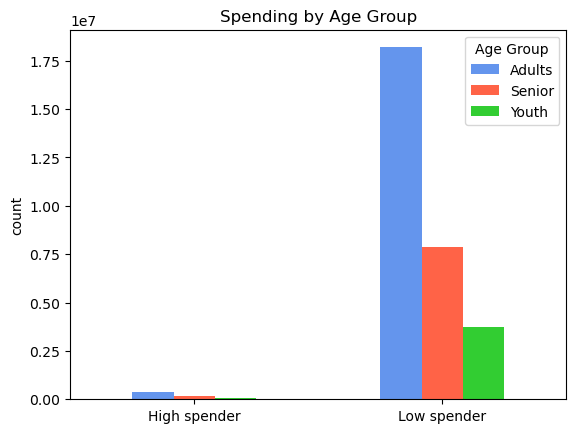

In [61]:
# Visualize a bar chart for the crosstab between spender_flag and Age Group
SpenderAgeGroup_BarChart = Crosstab_SpenderAgeGroup.plot.bar(color=['#6495ED', '#FF6347', '#32CD32'])
plt.title('Spending by Age Group')
plt.xlabel('')
plt.ylabel('count')
plt.xticks(rotation=0)

In [62]:
# Export the Bar Chart
SpenderAgeGroup_BarChart.figure.savefig(os.path.join(path, 'Analysis','Visualizations', 'SpenderAgeGroup_BarChart.png'))

# Aggregate the max, mean, and min variables on a customer-profile level for usage frequency and expenditure.

In [64]:
df.describe()

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_id,add_to_cart_order,reordered,aisle_id,department_id,prices,max_order,avg_price,median_days,Age,Number of Dependents,Income
count,3.181819e+07,3.181819e+07,3.181819e+07,3.181819e+07,3.181819e+07,3.181819e+07,3.181819e+07,3.181819e+07,3.181819e+07,3.181819e+07,3.181819e+07,3.181819e+07,3.181819e+07,3.181819e+07,3.181819e+07,3.181819e+07,3.181819e+07,3.181819e+07
mean,1.710886e+06,1.029585e+05,1.714541e+01,2.738960e+00,1.342437e+01,1.110160e+01,2.557855e+04,8.356159e+00,5.898793e-01,7.122403e+01,9.921874e+00,1.199307e+01,3.305855e+01,1.199307e+01,1.039413e+01,4.946628e+01,1.501470e+00,9.941234e+04
std,9.873075e+05,5.945291e+04,1.753593e+01,2.090239e+00,4.246230e+00,8.490516e+00,1.409623e+04,7.132051e+00,4.918554e-01,3.820554e+01,6.281233e+00,4.967520e+02,2.515210e+01,8.338097e+01,7.127570e+00,1.848773e+01,1.118842e+00,4.306926e+04
min,2.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,3.000000e+00,1.000000e+00,0.000000e+00,1.800000e+01,0.000000e+00,2.590300e+04
25%,8.561490e+05,5.147300e+04,5.000000e+00,1.000000e+00,1.000000e+01,5.000000e+00,1.353500e+04,3.000000e+00,0.000000e+00,3.100000e+01,4.000000e+00,4.200000e+00,1.300000e+01,7.391987e+00,6.000000e+00,3.300000e+01,0.000000e+00,6.698100e+04
50%,1.711214e+06,1.026510e+05,1.100000e+01,3.000000e+00,1.300000e+01,8.000000e+00,2.525600e+04,6.000000e+00,1.000000e+00,8.300000e+01,9.000000e+00,7.400000e+00,2.600000e+01,7.829827e+00,8.000000e+00,4.900000e+01,2.000000e+00,9.658100e+04
75%,2.565701e+06,1.543720e+05,2.400000e+01,5.000000e+00,1.600000e+01,1.400000e+01,3.794000e+04,1.100000e+01,1.000000e+00,1.070000e+02,1.600000e+01,1.130000e+01,4.700000e+01,8.259564e+00,1.300000e+01,6.500000e+01,3.000000e+00,1.279140e+05
max,3.421083e+06,2.062090e+05,9.900000e+01,6.000000e+00,2.300000e+01,3.000000e+01,4.968800e+04,1.450000e+02,1.000000e+00,1.340000e+02,2.100000e+01,9.999900e+04,9.900000e+01,2.500542e+04,3.000000e+01,8.100000e+01,3.000000e+00,5.939010e+05


In [65]:
# Group by customer profile variables
customer_profile_df = Updated_df.groupby(['Age Group', 'Income Group', 'loyalty_flag'])  # Modify this to your customer profile columns

# Aggregate max, mean, and min for usage frequency (e.g., 'days_since_prior_order') and expenditure (e.g., 'avg_price')
profile_agg = customer_profile_df.agg({
    'days_since_prior_order': ['max', 'mean', 'min'],
    'avg_price': ['max', 'mean', 'min']
})

# Display the aggregated result
profile_agg


days_since_prior_order             \
                                                           max       mean   
Age Group Income Group loyalty_flag                                         
Adults    HIGH         Loyal customer                     30.0   6.036011   
                       New customer                       30.0  16.656975   
                       Regular customer                   30.0  12.033414   
          LOW          Loyal customer                     30.0   6.085207   
                       New customer                       30.0  16.735461   
                       Regular customer                   30.0  12.280711   
          MIDDLE       Loyal customer                     30.0   6.133164   
                       New customer                       30.0  16.696996   
                       Regular customer                   30.0  12.107212   
Senior    HIGH         Loyal customer                     30.0   6.148018   
                       New customer                       30.0  16.692628   
                       Regular customer                   30.0  11.951682   
          LOW          Loyal customer                     30.0   6.144666   
                       New customer                       30.0  16.952055   
                       Regular customer                   30.0  11.974559   
          MIDDLE       Loyal customer                     30.0   6.130308   
                       New customer                       30.0  16.601280   
                       Regular customer                   30.0  12.101126   
Youth     HIGH         Loyal customer                     30.0   6.036362   
                       New customer                       30.0  17.662777   
                       Regular customer                   30.0  11.974567   
          LOW          Loyal customer                     30.0   6.144983   
                       New customer                       30.0  16.371494   
                       Regular customer                   30.0  12.158707   
          MIDDLE       Loyal customer                     30.0   6.106459   
                       New customer                       30.0  16.717376   
                       Regular customer                   30.0  12.074421   

                                                 avg_price              \
                                         min           max        mean   
Age Group Income Group loyalty_flag                                      
Adults    HIGH         Loyal customer    0.0   1142.965406   22.202411   
                       New customer      0.0  15006.940000   45.116374   
                       Regular customer  0.0   4174.447917   39.528459   
          LOW          Loyal customer    0.0     10.412367    6.746478   
                       New customer      0.0     12.000000    6.633221   
                       Regular customer  0.0     11.582407    6.740580   
          MIDDLE       Loyal customer    0.0   1262.955230    8.347292   
                       New customer      0.0   5135.893590   10.051700   
                       Regular customer  0.0   4506.269204    9.465087   
Senior    HIGH         Loyal customer    0.0   1626.189752   18.553819   
                       New customer      0.0   7414.485185   28.259974   
                       Regular customer  0.0   3695.987705   26.962064   
          LOW          Loyal customer    0.0      7.249587    6.537998   
                       New customer      0.0      7.968000    6.445080   
                       Regular customer  0.0      7.508696    6.525362   
          MIDDLE       Loyal customer    0.0   1185.684525    8.896641   
                       New customer      0.0  14042.512281    9.968206   
                       Regular customer  0.0   2522.939623    9.036077   
Youth     HIGH         Loyal customer    0.0   8794.882427  268.761612   
                       New customer      1.0  10209.987755  621.928158   
                       Regu

# Compare your customer profiles with regions and departments. 
Can you identify a link between them? Customers may demonstrate different behaviors across regions, which could make this information important.


### Compairing Department Preferences by Region

Different **regions** might have different preferences for specific **departments**. For instance:

- **Warmer climates**: Regions with warmer weather may see more customers purchasing from the **beverages** or **frozen foods** departments, as these products provide quick and refreshing options.
  
- **Colder regions**: Areas with colder climates might have more purchases from **canned goods** and **personal care** departments, as these items are practical for long-term storage and health-related needs.

By analyzing regional preferences for departments, we can identify product trends that are tied to climate, lifestyle, and cultural habits, which can be used to optimize inventory and marketing strategies.
.

In [68]:
# Using crosstab functiion on Region and Department
Cross_RegionDepartment = pd.crosstab(merged_sample_df['Region'], merged_sample_df['department'], dropna = False)

In [69]:
Cross_RegionDepartment

department,alcohol,babies,bakery,beverages,breakfast,canned goods,dairy eggs,deli,dry goods pasta,frozen,household,international,meat seafood,missing,other,pantry,personal care,pets,produce,snacks
Region,,,,,,,,,,,,,,,,,,,,
Midwest,80,74,624,752,276,572,1479,540,450,340,468,51,78,0,50,795,232,47,3570,1368
Northeast,40,37,260,564,46,468,1326,270,315,442,156,51,156,0,0,636,58,0,2346,570
South,40,185,936,1175,368,572,3009,270,360,578,468,102,234,52,0,1113,116,0,5814,1254
West,0,185,728,987,230,676,2652,864,180,612,208,51,156,52,50,901,174,47,3774,1140


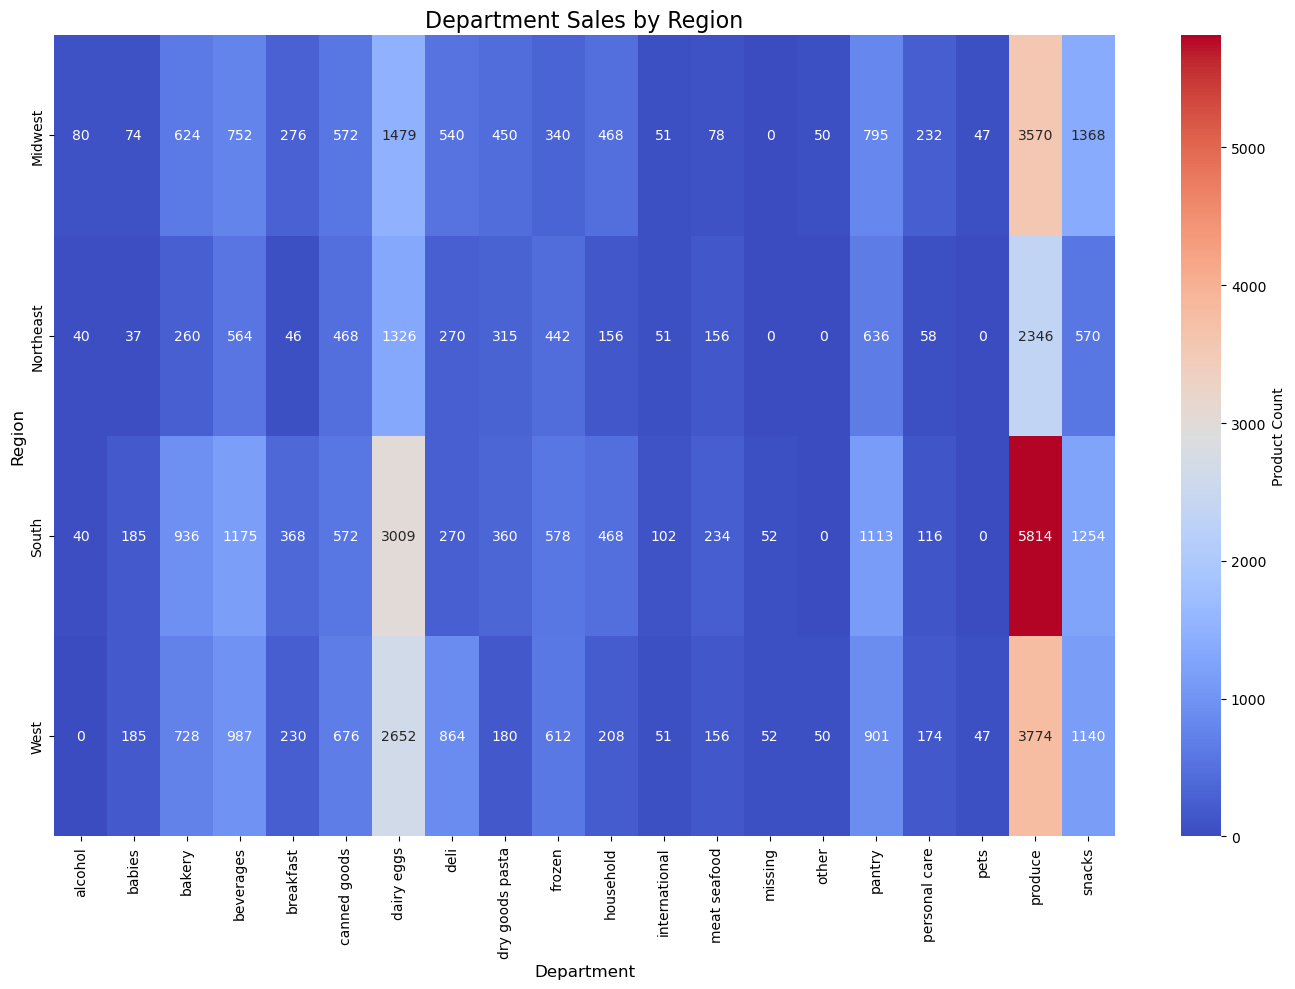

In [70]:
# Visualize a heatmap of Products ordered by Department across different regions
plt.figure(figsize=(14,10))
sns.heatmap(Cross_RegionDepartment, annot=True, cmap='coolwarm', fmt='g', cbar_kws={'label': 'Product Count'})
plt.title('Department Sales by Region', fontsize=16)
plt.xlabel('Department', fontsize=12)
plt.ylabel('Region', fontsize=12)
plt.tight_layout()
plt.show()

In [71]:
plt.savefig(os.path.join(path, 'Analysis', 'Visualizations', 'Department Sales by Region Heatmap.png'))

<Figure size 640x480 with 0 Axes>

In [72]:
# Using Crosstab function on loyalty with Family Status
Cross_LoyaltyFamilyStatus = pd.crosstab(df['loyalty_flag'], df['Family Status'], dropna = False)

### Comparing Loyalty by Family Status

**Loyalty:**  
This refers to customer behavior in terms of repeat purchases, engagement, or frequency of purchases.

**Family Status:**  
This category divides customers based on their family situation, such as **married**, **single**, or **living with parents**.

By analyzing **Loyalty by Family Status**, we can:

- **Identify if certain family types are more loyal to the brand**: Understanding which family statuses exhibit higher levels of loyalty can help tailor marketing efforts and promotional strategies.
  
- **Understand how family status impacts purchase behavior**: For example, **married customers** might make more frequent or larger purchases compared to **single customers** or those **living with parents**. This insight can guide the development of targeted campaigns designed for specific family types.


In [74]:
Cross_LoyaltyFamilyStatus

Family Status,divorced/widowed,living with parents and siblings,married,single
loyalty_flag,,,,
Loyal customer,856363,477427,7082418,1682772
New customer,519957,284608,4312464,1010023
Regular customer,1338674,752884,10953088,2547513


(array([0, 1, 2]),
 [Text(0, 0, 'Loyal customer'),
  Text(1, 0, 'New customer'),
  Text(2, 0, 'Regular customer')])

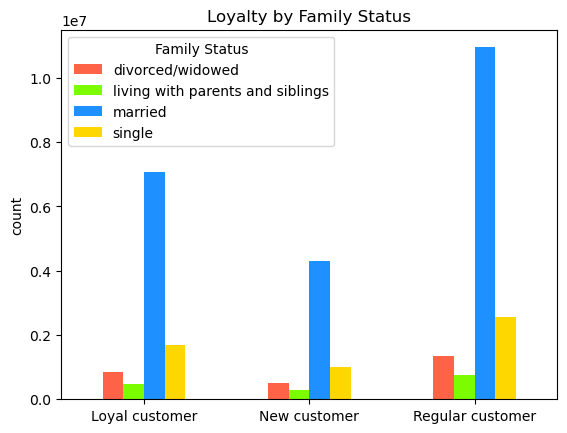

In [75]:
# Visualize a Bar Chart Loyalty across different family status of customers with customized colors
BarChart_LoyaltyFamilyStatus = Cross_LoyaltyFamilyStatus.plot.bar(color=['#FF6347', '#7CFC00', '#1E90FF', '#FFD700'])
plt.title('Loyalty by Family Status')
plt.xlabel('')
plt.ylabel('count')
plt.xticks(rotation=0)

In [76]:
# Export the Bar Chart
BarChart_LoyaltyFamilyStatus.figure.savefig(os.path.join(path, 'Analysis','Visualizations', 'BarChart_LoyaltyFamilyStatus.png'))

In [77]:
# Check value counts for Family Status 
FamilyStatus = df['Family Status'].value_counts(dropna = False)

In [78]:
FamilyStatus

Family Status
married                             22347970
single                               5240308
divorced/widowed                     2714994
living with parents and siblings     1514919
Name: count, dtype: int64

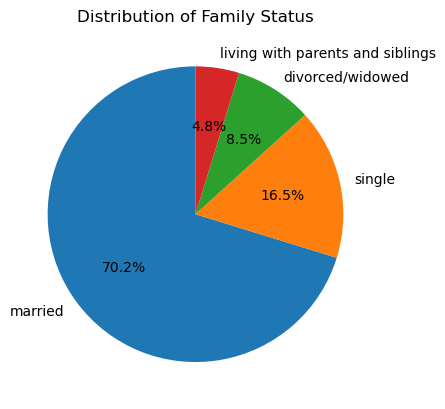

In [79]:
# Visualize a pie chart
PieChart_FamilyStatus = FamilyStatus.plot.pie(autopct='%1.1f%%', labels= ['married', 'single', 'divorced/widowed', 'living with parents and siblings'], startangle=90, color=['#FF6347', '#7CFC00', '#1E90FF', '#FFD700'])
# Hide the y-label
plt.ylabel('')  
plt.title('Distribution of Family Status')
plt.show()

### Compairing Age Group and Region

We can explore if there are any **age group** patterns within specific **regions**. For example:

- **Youth (<=25 years)** might prefer fast food, snacks, or convenience foods and may show higher purchasing activity in regions with easy access to such products.
- **Seniors (65+ years)** may be more inclined to buy health-related products, dietary goods, and personal care items, possibly reflecting a more health-conscious lifestyle.

By analyzing age group behavior across regions, we can identify which age groups are more prevalent in each region and how they interact with specific product categories. This can help tailor marketing strategies based on the unique preferences of each age group in different regions.


In [81]:
# Create a crosstab to compare Age Group with Region
Cross_AgeGroupRegion = pd.crosstab(merged_sample_df['Age Group'], merged_sample_df['Region'], dropna=False)

# Display the crosstab result
Cross_AgeGroupRegion


Region,Midwest,Northeast,South,West
Age Group,,,,
Adults,7731,4431,10500,8427
Senior,3077,2591,4343,3608
Youth,1038,719,1803,1632


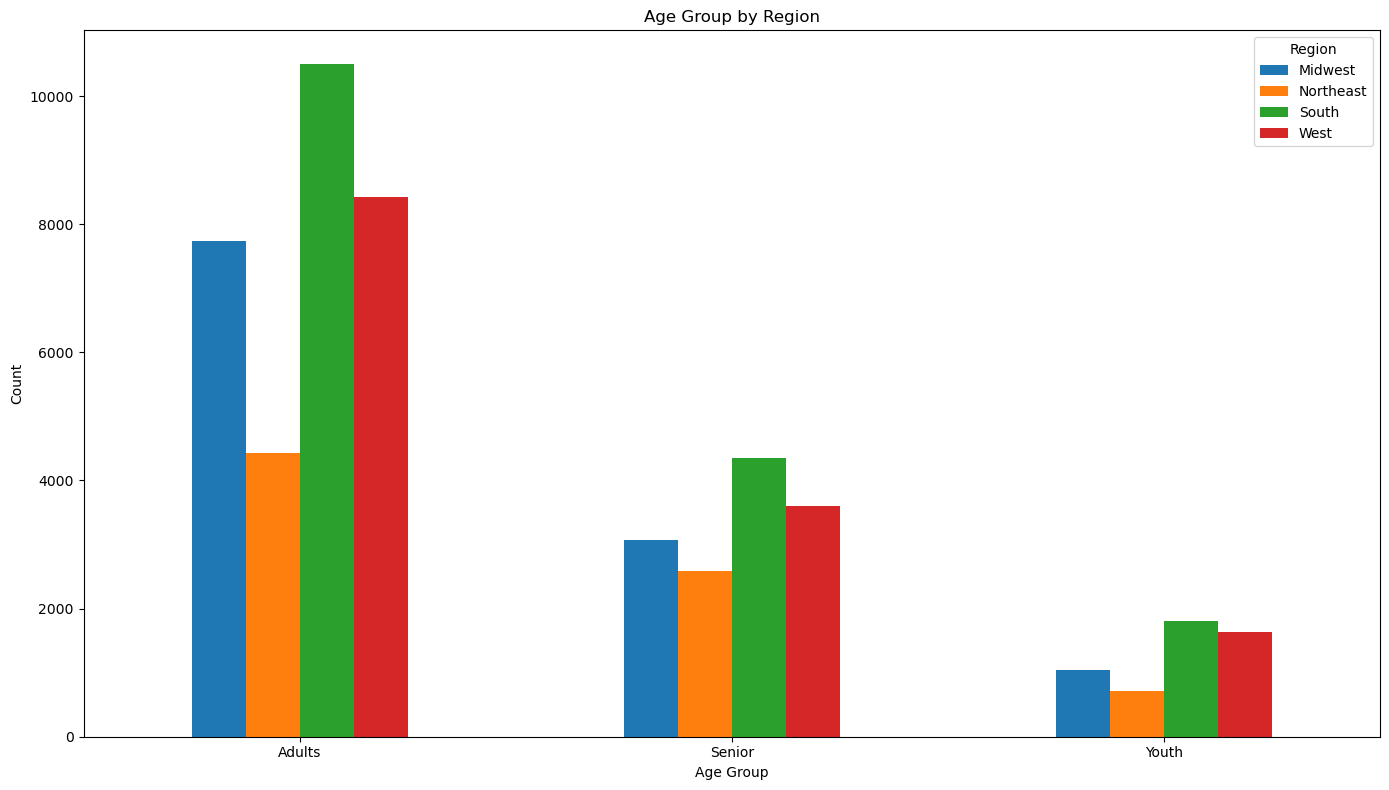

In [82]:
# Visualize the crosstab as a bar chart
Cross_AgeGroupRegion.plot(kind='bar', figsize=(14, 8), stacked=False)

plt.title('Age Group by Region')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.xticks(rotation=0)  # Rotate labels on x-axis for readability
plt.tight_layout()
plt.show()

### Comparing Income Group by Region

The goal of this analysis is to explore how **Income Groups** are distributed across different **Regions**. Understanding the relationship between income and region can help tailor marketing efforts, product offerings, and pricing strategies.

#### Key Insights:

- **Income Group Distribution**: By examining the distribution of **Low**, **Middle**, and **High** income groups across regions, we can identify patterns in consumer behavior. For example, certain regions may have a higher concentration of **middle-income** customers, while others may have a greater proportion of **high-income** customers.

- **Regional Preferences**: Some regions may show higher engagement with specific income groups. For example:
  - **Higher income groups** could be more concentrated in urban or affluent regions.
  - **Lower income groups** might be more prevalent in rural or economically disadvantaged areas.

In [84]:
# Create a crosstab to compare Income Group with Region
Cross_IncomeRegion = pd.crosstab(Updated_df['Income Group'], Updated_df['Region'], dropna=False)

# Display the crosstab result
Cross_IncomeRegion


Region,Midwest,Northeast,South,West
Income Group,,,,
HIGH,917697,678280,1213062,1010324
LOW,784456,587820,1081942,849875
MIDDLE,5565157,4203690,7437486,6073820


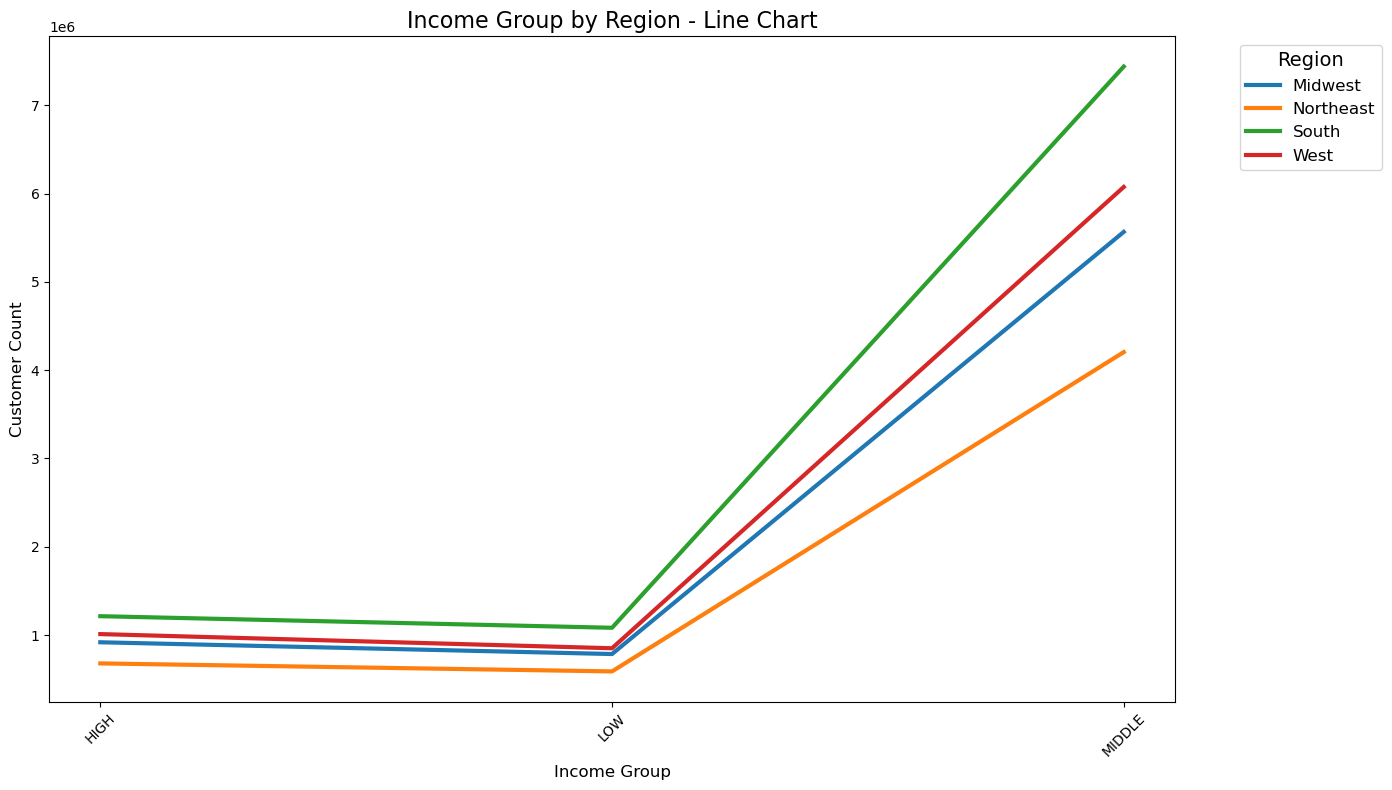

In [85]:
# Visualize the line chart with thicker lines for Income Group by Region
plt.figure(figsize=(14, 8))

# Plot each region's data with thicker lines
for region in Cross_IncomeRegion.columns:
    plt.plot(Cross_IncomeRegion.index, Cross_IncomeRegion[region], label=region, linewidth=3)  # Set the linewidth to 3

# Adding labels and title
plt.title('Income Group by Region - Line Chart', fontsize=16)
plt.xlabel('Income Group', fontsize=12)
plt.ylabel('Customer Count', fontsize=12)
plt.xticks(rotation=45)  # Rotate the x-axis labels to avoid overlap

# Add a legend to differentiate the regions
plt.legend(title='Region', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12, title_fontsize=14)

# Adjust layout for better spacing
plt.tight_layout()

# Show the plot
plt.show()



# Linking the Charts to Insights

By examining the crosstabs and visual charts across different comparisons, we can derive actionable insights to better understand customer behavior and optimize marketing and product strategies:

### 1. **Age Group and Region**
   - **Insights:**
     - **Youth** (<=25 years) tend to dominate in certain **regions** like the **South** and **West**, with a preference for **snacks** and **beverages**.
     - **Seniors** (65+ years) are more concentrated in **Midwest** and **Northeast**, with higher purchasing activity in **health-related products** and **personal care**.
   - **Actionable Takeaways:**
     - Tailor **youth-focused marketing** in regions where younger customers are predominant, especially for **snacks** and **beverages**.
     - Create targeted campaigns for **seniors** in specific regions, focusing on **health products** and **personal care**.

### 2. **Income Group and Region**
   - **Insights:**
     - **Middle-income** groups are concentrated in **regions** like the **Midwest** and **South**, while **high-income** customers are more prevalent in the **Northeast** and **West**.
     - **Low-income** groups are prominent in **rural regions**, reflecting the economic distribution.
   - **Actionable Takeaways:**
     - **Premium product lines** should target **high-income regions** for increased sales.
     - Design **discounted offers** or **budget-friendly products** for **low-income regions**, focusing on affordability and value for money.

### 3. **Loyalty by Family Status**
   - **Insights:**
     - **Married customers** or those with families tend to show higher **loyalty** compared to **single** customers.
     - **Single** customers may switch brands more frequently and might exhibit less repeat purchasing behavior.
   - **Actionable Takeaways:**
     - For **loyal customers**, offer **loyalty rewards**, subscription models, or family-focused promotions.
     - Develop **engagement strategies** for **single customers**, such as **product variety** and **exclusive offers** to encourage repeat purchases.

### 4. **Department Preferences by Region**
   - **Insights:**
     - **Regions with warmer climates** (e.g., **South** and **West**) show more purchases in **beverages**, **snacks**, and **frozen foods**.
     - **Colder regions** (e.g., **Midwest** and **Northeast**) demonstrate higher spending on **canned goods**, **personal care**, and **household products**.
   - **Actionable Takeaways:**
     - Target **regions with warmer climates** with more **refreshing beverages** and **snack promotions**.
     - For **colder regions**, promote **long-lasting** products like **canned goods** and **household essentials** to meet the needs of customers seeking products with longer shelf lives.

### Conclusion:
By visualizing these key comparisons and understanding the correlations between **age**, **income**, **loyalty**, and **region**, we can better tailor **marketing campaigns**, **inventory strategies**, and **product offerings** to meet the specific needs and preferences of customers in different regions.
